# **Retail Data Warehouse Analytics with DuckDB**

**Author:** Lucas Coutinho Boros
**Date:** May/2026
**Dataset:** [Instacart Market Basket Analysis](https://www.kaggle.com/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset)
**Tools:** DuckDB, Python, PyArrow, pandas (visualization only)

---

## ***Business Context***

In grocery retail, understanding purchasing behavior at scale is the foundation for inventory optimization, personalized marketing, and demand forecasting. Companies like iFood, Instacart, Drogasil, and McDonald's process millions of transactions daily, requiring analytical engines that can query large datasets in seconds without the overhead of a full database server.

This project builds a local data warehouse using **`DuckDB`**: an embedded analytical database that brings data warehouse performance to a Jupyter notebook. Using 3.4 million grocery orders from 200,000+ customers across 50,000 products, we demonstrate:

- **ETL pipeline:** CSV (raw) to Parquet (optimized) to DuckDB (analytical engine)
- **Star schema modeling:** fact and dimension tables for proper data warehouse design
- **SQL-first analytics:** window functions, CTEs, subqueries for business insights
- **Performance benchmarking:** DuckDB vs pandas on identical analytical queries

The entire analysis is done in **SQL through DuckDB**. **Pandas is used exclusively for visualization**.

---

## ***Project Pipeline***

1. Environment setup and DuckDB initial
2. ETL: CSV to Parquet conversion with performance benchmark
3. Star schema creation (fact + dimension tables)
4. Schema inspection and data dictionary
5. Business analytics with SQL (basket analysis, reorder patterns, peak hours)
6. Advanced SQL: window functions, CTEs, rankings
7. Customer behavior analysis (frequency, recency, loyalty)
8. DuckDB vs pandas performance benchmark
9. Export optimized outputs

---
# **STEP 1: Environment Setup + ETL Pipeline**

## 1. Environment Setup

#### ***Why `DuckDB` instead of `pandas` for this project?***

| Criteria | pandas | DuckDB |
|----------|--------|--------|
| Query language | Python API | SQL (industry standard) |
| JOINs on large tables | Slow, high memory | Optimized, columnar engine |
| Window functions | Complex `.transform()` chains | Native SQL `OVER()` syntax |
| 32M row aggregations | Seconds to minutes | Sub-second |
| Memory management | Loads everything into RAM | Lazy evaluation, spills to disk |
| Skill demonstrated | Python manipulation | SQL proficiency  |



!! DuckDB is not replacing pandas. It is the right tool for the right job: analytical queries on structured relational data at scale.  pandas remains superior for data cleaning, feature engineering, and ML pipelines. !!

In [1]:
# Importing libraries
## DuckDB as the analytical engine
import duckdb

## Data formats and manipulation
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd
import numpy as np

## Visualization (the only role for pandas/matplotlib in this project)
import matplotlib.pyplot as plt
import seaborn as sns

## Utilities
import os
import time

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('ggplot')
sns.set_palette('deep')

# Initializing DuckDB with a persistent database file
## Using a .duckdb file instead of :memory: for data warehouse persistence
## Once created, we can reopen the database without reprocessing the raw data
DB_PATH = '../data/retail_warehouse.duckdb'
con = duckdb.connect(DB_PATH)

print(f"DuckDB version: {duckdb.__version__}")
print(f"Database file:  {DB_PATH}")
print(f"PyArrow version: {pa.__version__}")
print("Setup complete")

DuckDB version: 1.5.3
Database file:  ../data/retail_warehouse.duckdb
PyArrow version: 24.0.0
Setup complete


## 2. ETL Pipeline: CSV to Parquet to DuckDB

#### ***Why convert CSV to Parquet before loading into DuckDB?***

**CSV** is a row-oriented text format. Every query reads the entire file, even if you only need 2 columns out of 10. Parsing text to numbers happens at every read.

**Parquet** is a column-oriented binary format. Queries read only the columns they need. Types are preserved (int stays int, no re-parsing). Compression reduces file size by 3-10x.

In production data pipelines (Databricks, BigQuery, Snowflake), raw data lands as CSV/JSON and is immediately converted to Parquet. This ETL step is foundational for any data engineer role.

In [2]:
# Converting all CSV files to Parquet format
## This is the ETL step: Extract (CSV) -> Transform (type optimization) -> Load (Parquet)

RAW_DIR = '../data/raw'
PARQUET_DIR = '../data/parquet'
os.makedirs(PARQUET_DIR, exist_ok=True)

csv_files = [f for f in os.listdir(RAW_DIR) if f.endswith('.csv')]
print(f"Found {len(csv_files)} CSV files in {RAW_DIR}/\n")

conversion_results = []

for csv_file in sorted(csv_files):
    csv_path = os.path.join(RAW_DIR, csv_file)
    parquet_file = csv_file.replace('.csv', '.parquet')
    parquet_path = os.path.join(PARQUET_DIR, parquet_file)
    
    # Reading CSV with pandas (for conversion only)
    start = time.time()
    df_temp = pd.read_csv(csv_path)
    csv_read_time = time.time() - start
    
    # Writing to Parquet with PyArrow
    start = time.time()
    df_temp.to_parquet(parquet_path, engine='pyarrow', index=False)
    parquet_write_time = time.time() - start
    
    # Comparing file sizes
    csv_size = os.path.getsize(csv_path) / (1024 * 1024)
    parquet_size = os.path.getsize(parquet_path) / (1024 * 1024)
    compression_ratio = csv_size / parquet_size if parquet_size > 0 else 0
    
    conversion_results.append({
        'file': csv_file,
        'rows': len(df_temp),
        'cols': len(df_temp.columns),
        'csv_mb': round(csv_size, 2),
        'parquet_mb': round(parquet_size, 2),
        'compression': f'{compression_ratio:.1f}x',
        'csv_read_s': round(csv_read_time, 2)
    })
    
    print(f"  {csv_file:<35} {len(df_temp):>10,} rows | CSV: {csv_size:.1f} MB -> Parquet: {parquet_size:.1f} MB ({compression_ratio:.1f}x compression)")

# Cleaning up temporary dataframe
del df_temp

print(f"\nETL conversion complete. Parquet files saved to {PARQUET_DIR}/")

Found 6 CSV files in ../data/raw/

  aisles.csv                                 134 rows | CSV: 0.0 MB -> Parquet: 0.0 MB (0.6x compression)
  departments.csv                             21 rows | CSV: 0.0 MB -> Parquet: 0.0 MB (0.1x compression)
  order_products__prior.csv           32,434,489 rows | CSV: 550.8 MB -> Parquet: 112.4 MB (4.9x compression)
  order_products__train.csv            1,384,617 rows | CSV: 23.5 MB -> Parquet: 4.8 MB (4.9x compression)
  orders.csv                           3,421,083 rows | CSV: 103.9 MB -> Parquet: 26.3 MB (4.0x compression)
  products.csv                            49,688 rows | CSV: 2.1 MB -> Parquet: 1.4 MB (1.5x compression)

ETL conversion complete. Parquet files saved to ../data/parquet/


In [3]:
# Creating the star schema in DuckDB from Parquet files
## Fact tables: orders, order_products (transactional data)
## Dimension tables: products, aisles, departments (descriptive attributes)

print("=" * 60)
print("  CREATING STAR SCHEMA IN DUCKDB")
print("=" * 60)

# Dimension tables (small, descriptive)
start = time.time()

con.execute(f"""
    CREATE OR REPLACE TABLE dim_departments AS 
    SELECT * FROM read_parquet('{PARQUET_DIR}/departments.parquet')
""")

con.execute(f"""
    CREATE OR REPLACE TABLE dim_aisles AS 
    SELECT * FROM read_parquet('{PARQUET_DIR}/aisles.parquet')
""")

con.execute(f"""
    CREATE OR REPLACE TABLE dim_products AS 
    SELECT * FROM read_parquet('{PARQUET_DIR}/products.parquet')
""")

# Fact tables (large, transactional)
con.execute(f"""
    CREATE OR REPLACE TABLE fact_orders AS 
    SELECT * FROM read_parquet('{PARQUET_DIR}/orders.parquet')
""")

con.execute(f"""
    CREATE OR REPLACE TABLE fact_order_products_prior AS 
    SELECT * FROM read_parquet('{PARQUET_DIR}/order_products__prior.parquet')
""")

con.execute(f"""
    CREATE OR REPLACE TABLE fact_order_products_train AS 
    SELECT * FROM read_parquet('{PARQUET_DIR}/order_products__train.parquet')
""")

elapsed = time.time() - start
print(f"\n  Star schema created in {elapsed:.2f}s")

# Verifying all tables
tables = con.execute("SHOW TABLES").fetchdf()
print(f"\n  Tables in warehouse:")
for _, row in tables.iterrows():
    count = con.execute(f"SELECT COUNT(*) FROM {row['name']}").fetchone()[0]
    print(f"    {row['name']:<35} {count:>12,} rows")

  CREATING STAR SCHEMA IN DUCKDB

  Star schema created in 3.50s

  Tables in warehouse:
    dim_aisles                                   134 rows
    dim_departments                               21 rows
    dim_products                              49,688 rows
    fact_order_products_prior             32,434,489 rows
    fact_order_products_train              1,384,617 rows
    fact_orders                            3,421,083 rows


In [4]:
# Inspecting the schema of each table
## Understanding columns, types, and relationships before writing queries

print("=" * 60)
print("  SCHEMA INSPECTION")
print("=" * 60)

for table in ['dim_departments', 'dim_aisles', 'dim_products', 'fact_orders', 
              'fact_order_products_prior', 'fact_order_products_train']:
    print(f"\n-- {table} --")
    schema = con.execute(f"DESCRIBE {table}").fetchdf()
    for _, row in schema.iterrows():
        print(f"  {row['column_name']:<25} {row['column_type']}")

  SCHEMA INSPECTION

-- dim_departments --
  department_id             BIGINT
  department                VARCHAR

-- dim_aisles --
  aisle_id                  BIGINT
  aisle                     VARCHAR

-- dim_products --
  product_id                BIGINT
  product_name              VARCHAR
  aisle_id                  BIGINT
  department_id             BIGINT

-- fact_orders --
  order_id                  BIGINT
  user_id                   BIGINT
  eval_set                  VARCHAR
  order_number              BIGINT
  order_dow                 BIGINT
  order_hour_of_day         BIGINT
  days_since_prior_order    DOUBLE

-- fact_order_products_prior --
  order_id                  BIGINT
  product_id                BIGINT
  add_to_cart_order         BIGINT
  reordered                 BIGINT

-- fact_order_products_train --
  order_id                  BIGINT
  product_id                BIGINT
  add_to_cart_order         BIGINT
  reordered                 BIGINT


In [5]:
# Previewing the first rows of each table via SQL
## Confirming data loaded correctly and understanding the content

print("-- dim_departments (product departments) --")
con.execute("SELECT * FROM dim_departments LIMIT 5").fetchdf()

-- dim_departments (product departments) --


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [2]:
# Previewing dimension and fact tables
print("-- dim_products (sample) --")
display(con.execute("SELECT * FROM dim_products LIMIT 5").fetchdf())

print("\n-- fact_orders (sample) --")
display(con.execute("SELECT * FROM fact_orders LIMIT 5").fetchdf())

print("\n-- fact_order_products_prior (sample) --")
display(con.execute("SELECT * FROM fact_order_products_prior LIMIT 5").fetchdf())

-- dim_products (sample) --


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13



-- fact_orders (sample) --


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.00
2,473747,1,prior,3,3,12,21.00
3,2254736,1,prior,4,4,7,29.00
4,431534,1,prior,5,4,15,28.00



-- fact_order_products_prior (sample) --


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


---
## 3. Data Dictionary

### Dimension tables (descriptive attributes)

| Table | Column | Type | Description |
|-------|--------|------|-------------|
| `dim_departments` | `department_id` | BIGINT | Unique department identifier (PK) |
| | `department` | VARCHAR | Department name (e.g., frozen, bakery, produce) |
| `dim_aisles` | `aisle_id` | BIGINT | Unique aisle identifier (PK) |
| | `aisle` | VARCHAR | Aisle name (e.g., fresh fruits, yogurt, energy bars) |
| `dim_products` | `product_id` | BIGINT | Unique product identifier (PK) |
| | `product_name` | VARCHAR | Full product name |
| | `aisle_id` | BIGINT | FK to dim_aisles |
| | `department_id` | BIGINT | FK to dim_departments |

### Fact tables (transactional data)

| Table | Column | Type | Description |
|-------|--------|------|-------------|
| `fact_orders` | `order_id` | BIGINT | Unique order identifier (PK) |
| | `user_id` | BIGINT | Customer identifier (anonymized) |
| | `eval_set` | VARCHAR | Dataset split: prior, train, or test |
| | `order_number` | BIGINT | Sequential order count per customer (1 = first order) |
| | `order_dow` | BIGINT | Day of week the order was placed (0 = Sunday) |
| | `order_hour_of_day` | BIGINT | Hour of day the order was placed (0-23) |
| | `days_since_prior_order` | DOUBLE | Days since the previous order (NULL for first orders) |
| `fact_order_products_prior` | `order_id` | BIGINT | FK to fact_orders |
| | `product_id` | BIGINT | FK to dim_products |
| | `add_to_cart_order` | BIGINT | Sequence in which the product was added to cart |
| | `reordered` | BIGINT | 1 = customer ordered this product before, 0 = first time |
| `fact_order_products_train` | Same structure as prior | | Training set subset |

### Star schema relationships
- `fact_orders` 1:N `fact_order_products` (one order contains many products)
- `fact_order_products` N:1 `dim_products` (each line references one product)
- `dim_products` N:1 `dim_aisles` (each product belongs to one aisle)
- `dim_products` N:1 `dim_departments` (each product belongs to one department)

### Volume summary
| Table | Rows | Role |
|-------|------|------|
| `dim_departments` | 21 | Dimension |
| `dim_aisles` | 134 | Dimension |
| `dim_products` | 49,688 | Dimension |
| `fact_orders` | 3,421,083 | Fact |
| `fact_order_products_prior` | 32,434,489 | Fact |
| `fact_order_products_train` | 1,384,617 | Fact |

---
# **STEP 2: Business Analytics with SQL**

## 4. Business Analytics - Core Metrics

All analysis from this point forward is done in **SQL through DuckDB**. Pandas is used only to receive query results for visualization. This demonstrates SQL proficiency for analytical roles where SQL is the primary tool for data exploration.

### Why SQL-first matters for the job market
In companies like iFood, Nubank, Boticario, and Itau, the data lives in warehouses (BigQuery, Snowflake, Redshift). Data analysts and scientists write SQL daily to answer business questions. Demonstrating complex SQL (JOINs, window functions, CTEs) in a portfolio project signals readiness for these environments.

In [3]:
# Dataset overview - answering foundational business questions via SQL
## Using scalar subqueries (each one runs independently, fast)

start = time.time()

overview = con.execute("""
    SELECT 
        (SELECT COUNT(DISTINCT user_id) FROM fact_orders) AS total_customers,
        (SELECT COUNT(DISTINCT order_id) FROM fact_orders) AS total_orders,
        (SELECT COUNT(*) FROM dim_products) AS total_products,
        (SELECT COUNT(*) FROM dim_aisles) AS total_aisles,
        (SELECT COUNT(*) FROM dim_departments) AS total_departments,
        ROUND(
            (SELECT COUNT(DISTINCT order_id) FROM fact_orders) * 1.0 / 
            (SELECT COUNT(DISTINCT user_id) FROM fact_orders), 1
        ) AS avg_orders_per_customer
""").fetchdf()

elapsed = time.time() - start

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
for col in overview.columns:
    print(f"  {col:<30} {overview[col].values[0]:>12,}")
print(f"\n  Query time: {elapsed:.2f}s")

  DATASET OVERVIEW
  total_customers                     206,209
  total_orders                      3,421,083
  total_products                       49,688
  total_aisles                            134
  total_departments                        21
  avg_orders_per_customer                16.6

  Query time: 2.89s


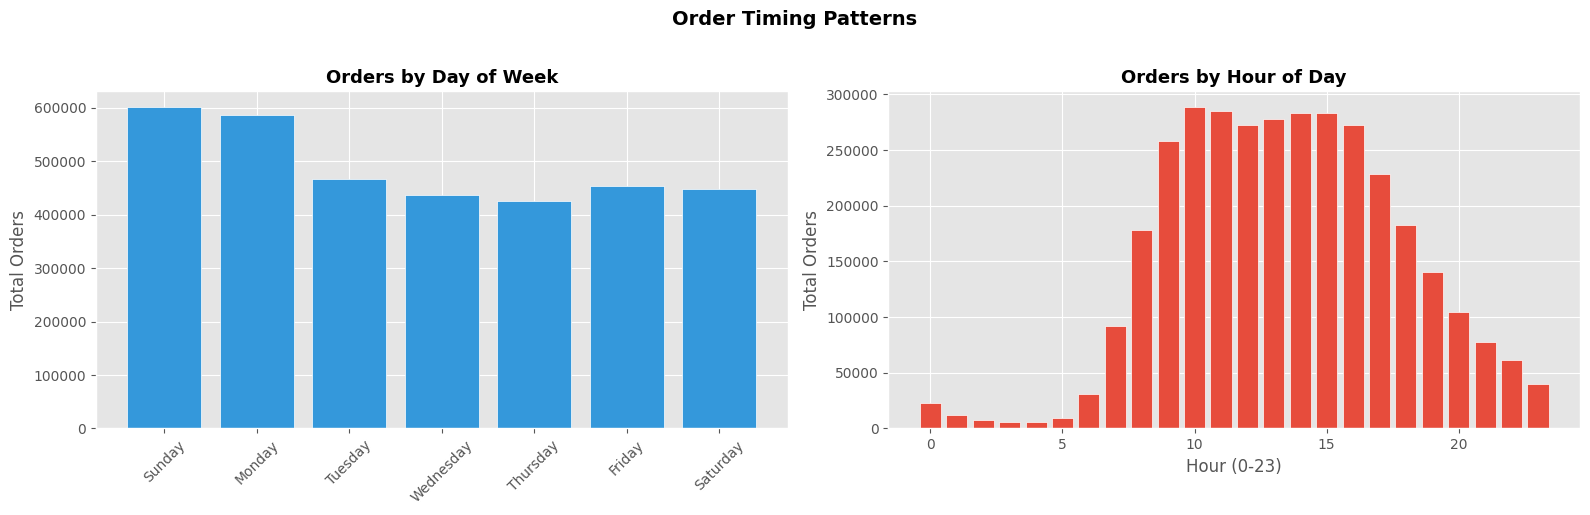

Peak day:   Sunday
Peak hour:  10


In [4]:
# When do customers place orders?
## Analyzing day of week and hour of day patterns

# Orders by day of week
dow_query = con.execute("""
    SELECT 
        order_dow,
        CASE order_dow
            WHEN 0 THEN 'Sunday'
            WHEN 1 THEN 'Monday'
            WHEN 2 THEN 'Tuesday'
            WHEN 3 THEN 'Wednesday'
            WHEN 4 THEN 'Thursday'
            WHEN 5 THEN 'Friday'
            WHEN 6 THEN 'Saturday'
        END AS day_name,
        COUNT(*) AS total_orders,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct_of_total
    FROM fact_orders
    GROUP BY order_dow
    ORDER BY order_dow
""").fetchdf()

# Orders by hour of day
hour_query = con.execute("""
    SELECT 
        order_hour_of_day AS hour,
        COUNT(*) AS total_orders,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct_of_total
    FROM fact_orders
    GROUP BY order_hour_of_day
    ORDER BY order_hour_of_day
""").fetchdf()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(dow_query['day_name'], dow_query['total_orders'], color='#3498db', edgecolor='white')
axes[0].set_title('Orders by Day of Week', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Orders')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(hour_query['hour'], hour_query['total_orders'], color='#e74c3c', edgecolor='white')
axes[1].set_title('Orders by Hour of Day', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Orders')
axes[1].set_xlabel('Hour (0-23)')

plt.suptitle('Order Timing Patterns', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/order_timing_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print("Peak day:  ", dow_query.loc[dow_query['total_orders'].idxmax(), 'day_name'])
print("Peak hour: ", hour_query.loc[hour_query['total_orders'].idxmax(), 'hour'])

-- Basket Size Statistics --

  avg_basket           10.1
  median_basket        8.0
  min_basket           1
  max_basket           145
  std_basket           7.5


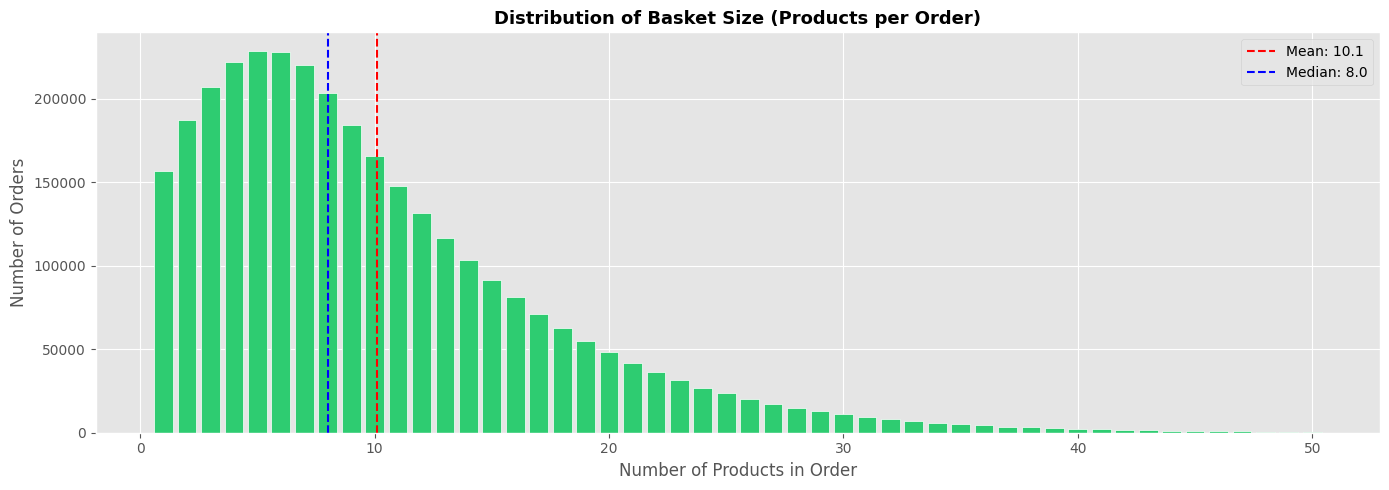

In [5]:
# Basket size analysis - how many products per order?
## Using a JOIN between fact_orders and fact_order_products_prior

basket_query = con.execute("""
    SELECT 
        basket_size,
        COUNT(*) AS num_orders,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct_of_orders
    FROM (
        SELECT 
            order_id,
            COUNT(*) AS basket_size
        FROM fact_order_products_prior
        GROUP BY order_id
    ) sub
    GROUP BY basket_size
    ORDER BY basket_size
""").fetchdf()

# Summary statistics via SQL
basket_stats = con.execute("""
    SELECT 
        ROUND(AVG(basket_size), 1) AS avg_basket,
        ROUND(MEDIAN(basket_size), 1) AS median_basket,
        MIN(basket_size) AS min_basket,
        MAX(basket_size) AS max_basket,
        ROUND(STDDEV(basket_size), 1) AS std_basket
    FROM (
        SELECT order_id, COUNT(*) AS basket_size
        FROM fact_order_products_prior
        GROUP BY order_id
    )
""").fetchdf()

print("-- Basket Size Statistics --\n")
for col in basket_stats.columns:
    print(f"  {col:<20} {basket_stats[col].values[0]}")

# Visualization (limiting to basket sizes 1-50 for readability)
basket_plot = basket_query[basket_query['basket_size'] <= 50]
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(basket_plot['basket_size'], basket_plot['num_orders'], color='#2ecc71', edgecolor='white')
ax.set_title('Distribution of Basket Size (Products per Order)', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Products in Order')
ax.set_ylabel('Number of Orders')
ax.axvline(basket_stats['avg_basket'].values[0], color='red', linestyle='--', 
           label=f"Mean: {basket_stats['avg_basket'].values[0]:.1f}")
ax.axvline(basket_stats['median_basket'].values[0], color='blue', linestyle='--',
           label=f"Median: {basket_stats['median_basket'].values[0]:.1f}")
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/basket_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Query time: 5.815s (scanning 32M rows)

-- Top 20 Products by Order Frequency --

            product_name department  times_ordered  times_reordered  reorder_rate_pct
                  Banana    produce         472565        398609.00             84.40
  Bag of Organic Bananas    produce         379450        315913.00             83.30
    Organic Strawberries    produce         264683        205845.00             77.80
    Organic Baby Spinach    produce         241921        186884.00             77.30
    Organic Hass Avocado    produce         213584        170131.00             79.70
         Organic Avocado    produce         176815        134044.00             75.80
             Large Lemon    produce         152657        106255.00             69.60
            Strawberries    produce         142951         99802.00             69.80
                   Limes    produce         140627         95768.00             68.10
      Organic Whole Milk dairy eggs         137905        

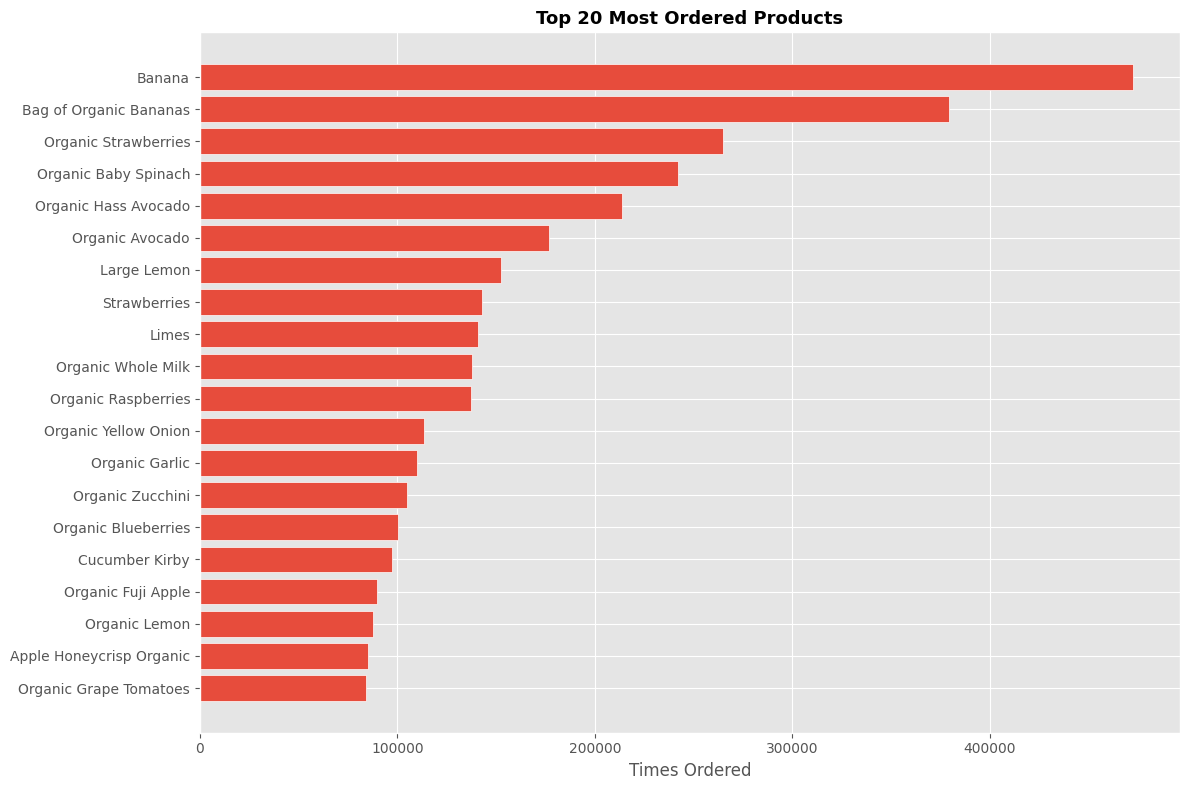

In [6]:
# Top 20 most ordered products
## First real JOIN: fact_order_products + dim_products + dim_departments
## This query touches 32M rows and returns in milliseconds via DuckDB

start = time.time()

top_products = con.execute("""
    SELECT 
        p.product_name,
        d.department,
        COUNT(*) AS times_ordered,
        SUM(fop.reordered) AS times_reordered,
        ROUND(SUM(fop.reordered) * 100.0 / COUNT(*), 1) AS reorder_rate_pct
    FROM fact_order_products_prior fop
    JOIN dim_products p ON fop.product_id = p.product_id
    JOIN dim_departments d ON p.department_id = d.department_id
    GROUP BY p.product_name, d.department
    ORDER BY times_ordered DESC
    LIMIT 20
""").fetchdf()

elapsed = time.time() - start
print(f"Query time: {elapsed:.3f}s (scanning 32M rows)\n")

print("-- Top 20 Products by Order Frequency --\n")
print(top_products.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top_products['product_name'][::-1], top_products['times_ordered'][::-1], 
        color='#e74c3c', edgecolor='white')
ax.set_title('Top 20 Most Ordered Products', fontsize=13, fontweight='bold')
ax.set_xlabel('Times Ordered')
plt.tight_layout()
plt.savefig('../outputs/top_20_products.png', dpi=150, bbox_inches='tight')
plt.show()

-- Reorder Behavior --

  Overall reorder rate: 58.97%
  Total product orders: 32,434,489
  Reorders:             19,126,536.0
  First-time purchases: 13,307,953.0


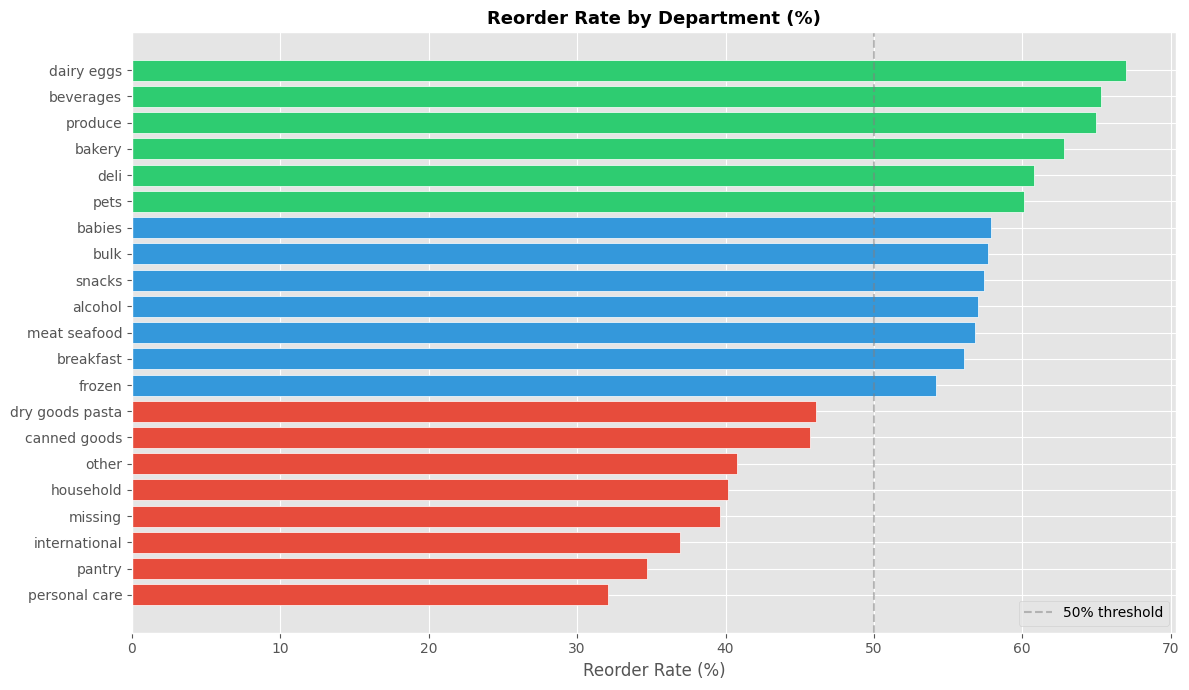

In [7]:
# Reorder analysis - what percentage of products are reorders?
## Key business metric: customer loyalty indicator

reorder_stats = con.execute("""
    SELECT 
        ROUND(SUM(reordered) * 100.0 / COUNT(*), 2) AS overall_reorder_rate,
        COUNT(*) AS total_product_orders,
        SUM(reordered) AS total_reorders,
        COUNT(*) - SUM(reordered) AS total_first_time
    FROM fact_order_products_prior
""").fetchdf()

print("-- Reorder Behavior --\n")
print(f"  Overall reorder rate: {reorder_stats['overall_reorder_rate'].values[0]}%")
print(f"  Total product orders: {reorder_stats['total_product_orders'].values[0]:,}")
print(f"  Reorders:             {reorder_stats['total_reorders'].values[0]:,}")
print(f"  First-time purchases: {reorder_stats['total_first_time'].values[0]:,}")

# Reorder rate by department
dept_reorder = con.execute("""
    SELECT 
        d.department,
        COUNT(*) AS total_orders,
        ROUND(SUM(fop.reordered) * 100.0 / COUNT(*), 1) AS reorder_rate_pct
    FROM fact_order_products_prior fop
    JOIN dim_products p ON fop.product_id = p.product_id
    JOIN dim_departments d ON p.department_id = d.department_id
    GROUP BY d.department
    HAVING COUNT(*) > 1000
    ORDER BY reorder_rate_pct DESC
""").fetchdf()

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#2ecc71' if x >= 60 else '#3498db' if x >= 50 else '#e74c3c' 
          for x in dept_reorder['reorder_rate_pct']]
ax.barh(dept_reorder['department'][::-1], dept_reorder['reorder_rate_pct'][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_title('Reorder Rate by Department (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Reorder Rate (%)')
ax.axvline(50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/reorder_rate_by_department.png', dpi=150, bbox_inches='tight')
plt.show()

---
# **STEP 3: Advanced SQL - Window Functions, CTEs, and Customer Analytics**

## 5. Advanced SQL Analytics

This section demonstrates SQL techniques commonly tested in data analyst and data scientist interviews: **window functions** (RANK, ROW_NUMBER, LAG, running totals), **CTEs** (Common Table Expressions for readable multi-step queries), and **subqueries** for complex aggregations.

#### ***Why window functions matter?***
Window functions perform calculations across rows related to the current row without collapsing the result set. Unlike GROUP BY (which reduces rows), window functions preserve every row while adding analytical columns. This is how you answer questions like "what is the rank of this product within its department?" or "how does this order compare to the customer's previous order?"

In [8]:
# Top 3 products by order count within each department
## Window function: RANK() OVER(PARTITION BY department ORDER BY ...)
## This is a classic interview question: "find the top N per group"

start = time.time()

top_per_dept = con.execute("""
    WITH product_counts AS (
        SELECT 
            d.department,
            p.product_name,
            COUNT(*) AS times_ordered,
            RANK() OVER(
                PARTITION BY d.department 
                ORDER BY COUNT(*) DESC
            ) AS rank_in_dept
        FROM fact_order_products_prior fop
        JOIN dim_products p ON fop.product_id = p.product_id
        JOIN dim_departments d ON p.department_id = d.department_id
        GROUP BY d.department, p.product_name
    )
    SELECT department, product_name, times_ordered, rank_in_dept
    FROM product_counts
    WHERE rank_in_dept <= 3
    ORDER BY department, rank_in_dept
""").fetchdf()

elapsed = time.time() - start
print(f"Query time: {elapsed:.2f}s\n")
print("-- Top 3 Products per Department --\n")
print(top_per_dept.to_string(index=False))

Query time: 4.99s

-- Top 3 Products per Department --

     department                                     product_name  times_ordered  rank_in_dept
        alcohol                                  Sauvignon Blanc           8246             1
        alcohol                                       Chardonnay           6153             2
        alcohol                               Cabernet Sauvignon           6115             3
         babies Baby Food Stage 2 Blueberry Pear & Purple Carrot           8793             1
         babies            Spinach Peas & Pear Stage 2 Baby Food           8035             2
         babies            Gluten Free SpongeBob Spinach Littles           7083             3
         bakery                           100% Whole Wheat Bread          60816             1
         bakery               Organic Bread with 21 Whole Grains          23006             2
         bakery   Ezekiel 4:9 Bread Organic Sprouted Whole Grain          17789             3
    

-- Customer Frequency Segments --

frequency_segment  num_customers  pct_of_total  avg_orders  avg_days_gap
           Weekly          24670         12.00       39.60          5.30
         Biweekly          69468         33.70       19.30         10.60
          Monthly         112071         54.30        8.00         20.70

-- Customer Loyalty Segments --

  loyalty_segment  num_customers  pct_of_total  avg_orders
 Power User (50+)          11464          5.60       68.90
  Regular (20-49)          42467         20.60       30.20
Occasional (5-19)         128292         62.20        9.80
        New (1-4)          23986         11.60        4.00


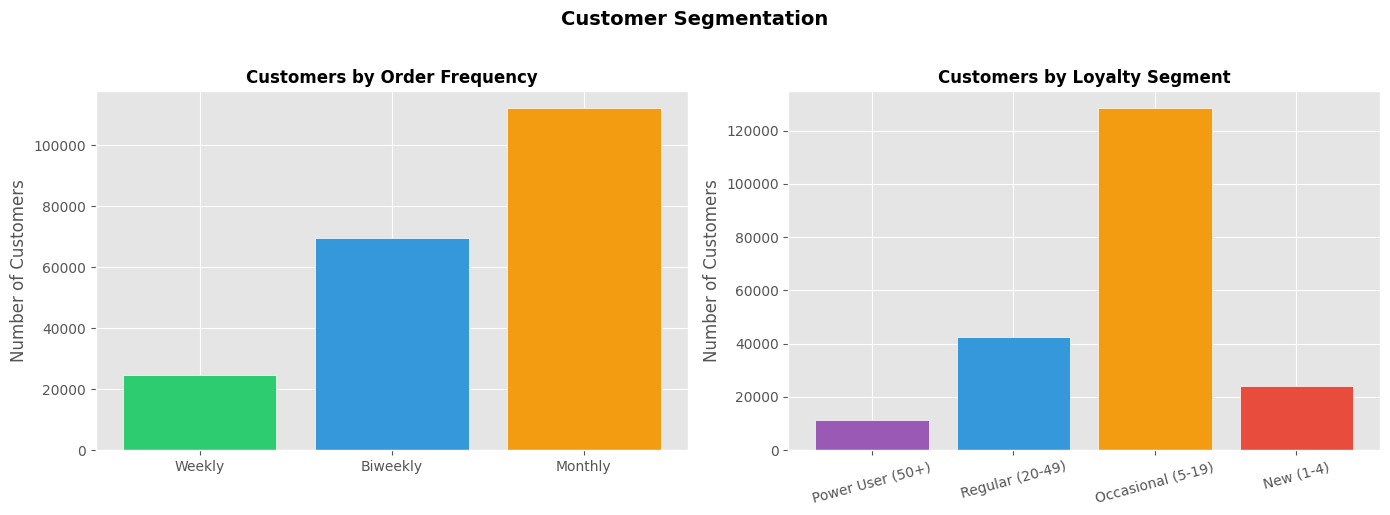

In [9]:
# Customer ordering behavior - frequency and recency analysis
## CTE for readability: first compute per-customer metrics, then classify

customer_behavior = con.execute("""
    WITH customer_metrics AS (
        SELECT 
            user_id,
            COUNT(DISTINCT order_id) AS total_orders,
            ROUND(AVG(days_since_prior_order), 1) AS avg_days_between_orders,
            MIN(order_number) AS first_order,
            MAX(order_number) AS last_order
        FROM fact_orders
        WHERE days_since_prior_order IS NOT NULL
        GROUP BY user_id
    ),
    classified AS (
        SELECT 
            *,
            CASE 
                WHEN avg_days_between_orders <= 7  THEN 'Weekly'
                WHEN avg_days_between_orders <= 14 THEN 'Biweekly'
                WHEN avg_days_between_orders <= 30 THEN 'Monthly'
                ELSE 'Infrequent'
            END AS frequency_segment,
            CASE
                WHEN total_orders >= 50 THEN 'Power User'
                WHEN total_orders >= 20 THEN 'Regular'
                WHEN total_orders >= 5  THEN 'Occasional'
                ELSE 'New'
            END AS loyalty_segment
        FROM customer_metrics
    )
    SELECT 
        frequency_segment,
        COUNT(*) AS num_customers,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct_of_total,
        ROUND(AVG(total_orders), 1) AS avg_orders,
        ROUND(AVG(avg_days_between_orders), 1) AS avg_days_gap
    FROM classified
    GROUP BY frequency_segment
    ORDER BY avg_days_gap
""").fetchdf()

print("-- Customer Frequency Segments --\n")
print(customer_behavior.to_string(index=False))

# Loyalty segments
loyalty = con.execute("""
    WITH customer_metrics AS (
        SELECT 
            user_id,
            COUNT(DISTINCT order_id) AS total_orders
        FROM fact_orders
        GROUP BY user_id
    )
    SELECT 
        CASE
            WHEN total_orders >= 50 THEN 'Power User (50+)'
            WHEN total_orders >= 20 THEN 'Regular (20-49)'
            WHEN total_orders >= 5  THEN 'Occasional (5-19)'
            ELSE 'New (1-4)'
        END AS loyalty_segment,
        COUNT(*) AS num_customers,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct_of_total,
        ROUND(AVG(total_orders), 1) AS avg_orders
    FROM customer_metrics
    GROUP BY loyalty_segment
    ORDER BY avg_orders DESC
""").fetchdf()

print("\n-- Customer Loyalty Segments --\n")
print(loyalty.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(customer_behavior['frequency_segment'], customer_behavior['num_customers'],
            color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'], edgecolor='white')
axes[0].set_title('Customers by Order Frequency', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Customers')

axes[1].bar(loyalty['loyalty_segment'], loyalty['num_customers'],
            color=['#9b59b6', '#3498db', '#f39c12', '#e74c3c'], edgecolor='white')
axes[1].set_title('Customers by Loyalty Segment', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Customer Segmentation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/customer_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

-- Department Pareto Analysis (80/20 Rule) --

     department  total_orders  pct_of_total  cumulative_pct  rank
        produce       9479291         29.23           29.23     1
     dairy eggs       5414016         16.69           45.92     2
         snacks       2887550          8.90           54.82     3
      beverages       2690129          8.29           63.11     4
         frozen       2236432          6.90           70.01     5
         pantry       1875577          5.78           75.79     6
         bakery       1176787          3.63           79.42     7
   canned goods       1068058          3.29           82.71     8
           deli       1051249          3.24           85.96     9
dry goods pasta        866627          2.67           88.63    10
      household        738666          2.28           90.90    11
      breakfast        709569          2.19           93.09    12
   meat seafood        708931          2.19           95.28    13
  personal care        447123

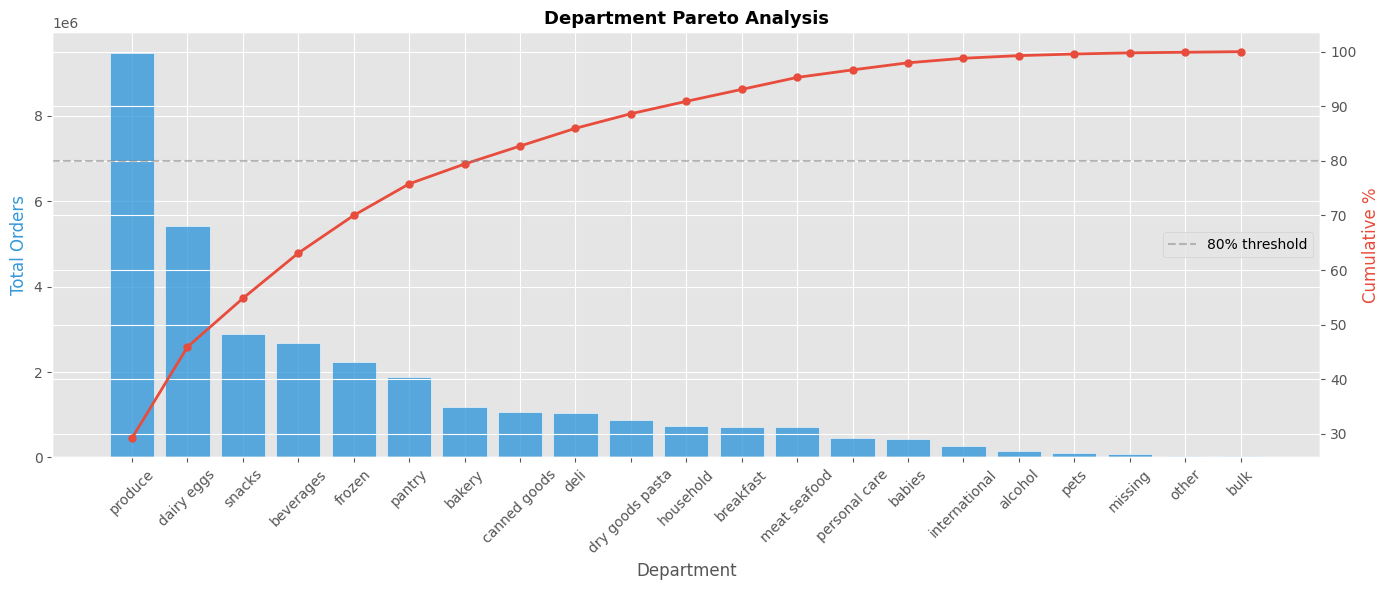

In [10]:
# Department share of total orders with cumulative percentage
## Window function: SUM() OVER(ORDER BY ...) for running totals
## Classic Pareto (80/20) analysis via SQL

dept_pareto = con.execute("""
    WITH dept_orders AS (
        SELECT 
            d.department,
            COUNT(*) AS total_orders
        FROM fact_order_products_prior fop
        JOIN dim_products p ON fop.product_id = p.product_id
        JOIN dim_departments d ON p.department_id = d.department_id
        GROUP BY d.department
    )
    SELECT 
        department,
        total_orders,
        ROUND(total_orders * 100.0 / SUM(total_orders) OVER(), 2) AS pct_of_total,
        ROUND(
            SUM(total_orders) OVER(ORDER BY total_orders DESC) * 100.0 / 
            SUM(total_orders) OVER(), 2
        ) AS cumulative_pct,
        ROW_NUMBER() OVER(ORDER BY total_orders DESC) AS rank
    FROM dept_orders
    ORDER BY total_orders DESC
""").fetchdf()

print("-- Department Pareto Analysis (80/20 Rule) --\n")
print(dept_pareto.to_string(index=False))

# How many departments account for 80% of orders?
depts_for_80 = dept_pareto[dept_pareto['cumulative_pct'] <= 80].shape[0]
print(f"\n  Departments covering 80% of orders: {depts_for_80} out of {len(dept_pareto)}")

# Visualization
fig, ax1 = plt.subplots(figsize=(14, 6))

bars = ax1.bar(dept_pareto['department'], dept_pareto['total_orders'], 
               color='#3498db', edgecolor='white', alpha=0.8)
ax1.set_ylabel('Total Orders', color='#3498db')
ax1.set_xlabel('Department')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(dept_pareto['department'], dept_pareto['cumulative_pct'], 
         color='#e74c3c', marker='o', linewidth=2, markersize=5)
ax2.axhline(80, color='gray', linestyle='--', alpha=0.5, label='80% threshold')
ax2.set_ylabel('Cumulative %', color='#e74c3c')
ax2.legend(loc='center right')

plt.title('Department Pareto Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/department_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Analyzing the gap between consecutive orders per customer
## Window function: LAG() to access the previous row's value
## This is how you compute "days since last order" from raw order data

order_gaps = con.execute("""
    SELECT 
        gap_bucket,
        num_orders,
        ROUND(num_orders * 100.0 / SUM(num_orders) OVER(), 1) AS pct
    FROM (
        SELECT 
            CASE 
                WHEN days_since_prior_order <= 7  THEN '01. Weekly (0-7d)'
                WHEN days_since_prior_order <= 14 THEN '02. Biweekly (8-14d)'
                WHEN days_since_prior_order <= 21 THEN '03. Triweekly (15-21d)'
                WHEN days_since_prior_order <= 30 THEN '04. Monthly (22-30d)'
                ELSE '05. Over 30 days'
            END AS gap_bucket,
            COUNT(*) AS num_orders
        FROM fact_orders
        WHERE days_since_prior_order IS NOT NULL
        GROUP BY gap_bucket
    )
    ORDER BY gap_bucket
""").fetchdf()

print("-- Days Between Orders Distribution --\n")
print(order_gaps.to_string(index=False))

# Stats
gap_stats = con.execute("""
    SELECT 
        ROUND(AVG(days_since_prior_order), 1) AS avg_gap,
        ROUND(MEDIAN(days_since_prior_order), 1) AS median_gap,
        ROUND(MODE(days_since_prior_order), 1) AS mode_gap
    FROM fact_orders
    WHERE days_since_prior_order IS NOT NULL
""").fetchdf()

print(f"\n  Average gap:  {gap_stats['avg_gap'].values[0]} days")
print(f"  Median gap:   {gap_stats['median_gap'].values[0]} days")
print(f"  Mode gap:     {gap_stats['mode_gap'].values[0]} days")

-- Days Between Orders Distribution --

            gap_bucket  num_orders   pct
     01. Weekly (0-7d)     1620033 50.40
  02. Biweekly (8-14d)      735651 22.90
03. Triweekly (15-21d)      307027  9.60
  04. Monthly (22-30d)      552163 17.20

  Average gap:  11.1 days
  Median gap:   7.0 days
  Mode gap:     30.0 days


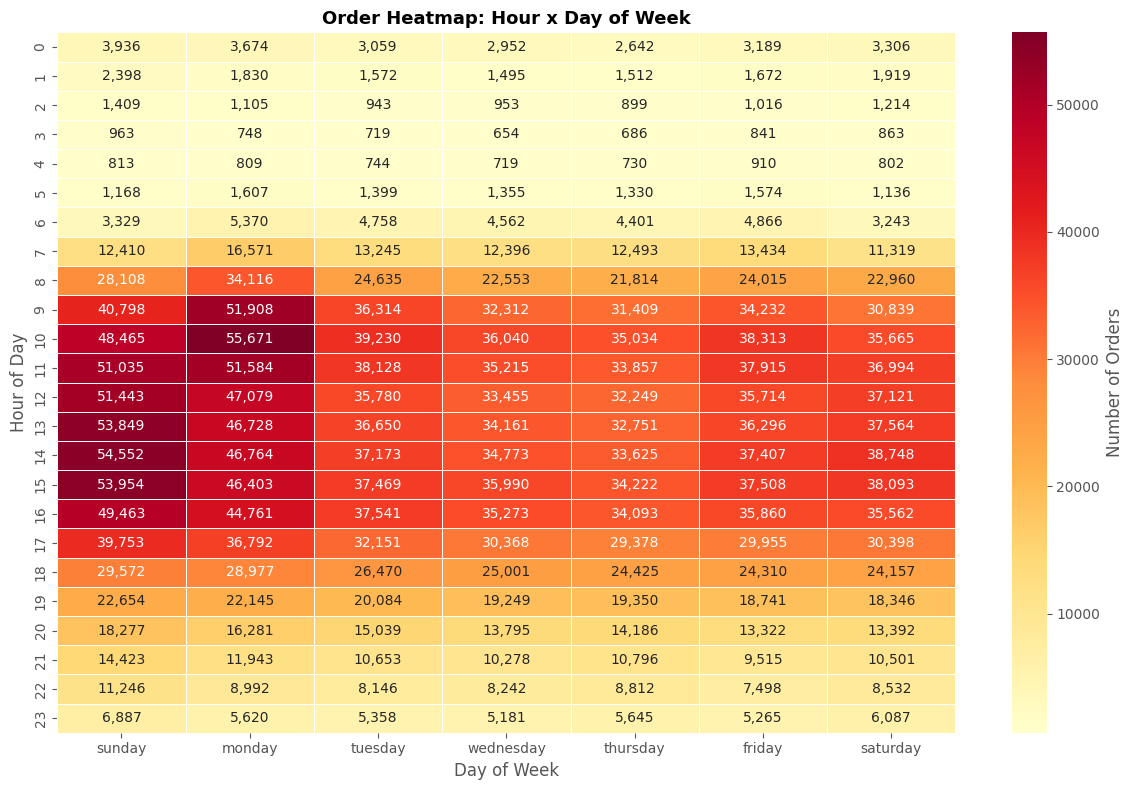

In [12]:
# Order heatmap: day of week x hour of day
## Pivoting in SQL using CASE WHEN for each day column
## Shows the busiest slots for operational planning

heatmap_data = con.execute("""
    SELECT 
        order_hour_of_day AS hour,
        SUM(CASE WHEN order_dow = 0 THEN 1 ELSE 0 END) AS sunday,
        SUM(CASE WHEN order_dow = 1 THEN 1 ELSE 0 END) AS monday,
        SUM(CASE WHEN order_dow = 2 THEN 1 ELSE 0 END) AS tuesday,
        SUM(CASE WHEN order_dow = 3 THEN 1 ELSE 0 END) AS wednesday,
        SUM(CASE WHEN order_dow = 4 THEN 1 ELSE 0 END) AS thursday,
        SUM(CASE WHEN order_dow = 5 THEN 1 ELSE 0 END) AS friday,
        SUM(CASE WHEN order_dow = 6 THEN 1 ELSE 0 END) AS saturday
    FROM fact_orders
    GROUP BY order_hour_of_day
    ORDER BY order_hour_of_day
""").fetchdf()

# Visualization
pivot = heatmap_data.set_index('hour')
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt=',.0f', linewidths=0.5,
            linecolor='white', ax=ax, cbar_kws={'label': 'Number of Orders'})
ax.set_title('Order Heatmap: Hour x Day of Week', fontsize=13, fontweight='bold')
ax.set_ylabel('Hour of Day')
ax.set_xlabel('Day of Week')
plt.tight_layout()
plt.savefig('../outputs/order_heatmap_hour_day.png', dpi=150, bbox_inches='tight')
plt.show()

---
# **STEP 4: DuckDB vs pandas Performance Benchmark + Final Documentation**

## 6. Performance Benchmark: DuckDB vs pandas

The core question: how much faster is DuckDB than pandas for analytical queries on 32M+ rows? We run three identical queries using both engines and compare execution time. This demonstrates why modern analytics teams adopt DuckDB, Polars, or similar engines instead of loading everything into pandas DataFrames.

In [13]:
# DuckDB vs pandas benchmark on identical queries
## Loading the largest table into pandas for fair comparison

print("Loading fact_order_products_prior into pandas (32M rows)...")
start = time.time()
df_prior = pd.read_parquet('../data/parquet/order_products__prior.parquet')
df_products = pd.read_parquet('../data/parquet/products.parquet')
df_departments = pd.read_parquet('../data/parquet/departments.parquet')
pandas_load_time = time.time() - start
print(f"  Loaded in {pandas_load_time:.2f}s | Memory: {df_prior.memory_usage(deep=True).sum()/1024**2:.0f} MB\n")

benchmarks = []

# Benchmark 1: Simple aggregation (basket size per order)
print("=" * 60)
print("  BENCHMARK 1: Basket size per order (32M rows)")
print("=" * 60)

start = time.time()
r1_duck = con.execute("""
    SELECT order_id, COUNT(*) AS basket_size
    FROM fact_order_products_prior
    GROUP BY order_id
""").fetchdf()
duck_t1 = time.time() - start

start = time.time()
r1_pandas = df_prior.groupby('order_id').size().reset_index(name='basket_size')
pandas_t1 = time.time() - start

benchmarks.append({'query': 'Basket size (GROUP BY)', 'duckdb_s': round(duck_t1, 3), 
                   'pandas_s': round(pandas_t1, 3)})
print(f"  DuckDB: {duck_t1:.3f}s | pandas: {pandas_t1:.3f}s | Speedup: {pandas_t1/duck_t1:.1f}x")

# Benchmark 2: JOIN + aggregation (top products with department)
print(f"\n{'=' * 60}")
print("  BENCHMARK 2: Top products with JOIN (32M + 50K rows)")
print("=" * 60)

start = time.time()
r2_duck = con.execute("""
    SELECT p.product_name, d.department, COUNT(*) AS times_ordered
    FROM fact_order_products_prior fop
    JOIN dim_products p ON fop.product_id = p.product_id
    JOIN dim_departments d ON p.department_id = d.department_id
    GROUP BY p.product_name, d.department
    ORDER BY times_ordered DESC
    LIMIT 20
""").fetchdf()
duck_t2 = time.time() - start

start = time.time()
merged = df_prior.merge(df_products, on='product_id').merge(df_departments, on='department_id')
r2_pandas = (merged.groupby(['product_name', 'department']).size()
             .reset_index(name='times_ordered')
             .sort_values('times_ordered', ascending=False).head(20))
pandas_t2 = time.time() - start

benchmarks.append({'query': 'Top products (JOIN + GROUP BY)', 'duckdb_s': round(duck_t2, 3),
                   'pandas_s': round(pandas_t2, 3)})
print(f"  DuckDB: {duck_t2:.3f}s | pandas: {pandas_t2:.3f}s | Speedup: {pandas_t2/duck_t2:.1f}x")

# Benchmark 3: Window function (rank per department)
print(f"\n{'=' * 60}")
print("  BENCHMARK 3: Rank per department (window function)")
print("=" * 60)

start = time.time()
r3_duck = con.execute("""
    WITH product_counts AS (
        SELECT p.department_id, p.product_name, COUNT(*) AS cnt,
               RANK() OVER(PARTITION BY p.department_id ORDER BY COUNT(*) DESC) AS rnk
        FROM fact_order_products_prior fop
        JOIN dim_products p ON fop.product_id = p.product_id
        GROUP BY p.department_id, p.product_name
    )
    SELECT * FROM product_counts WHERE rnk <= 3
""").fetchdf()
duck_t3 = time.time() - start

start = time.time()
merged2 = df_prior.merge(df_products[['product_id', 'product_name', 'department_id']], on='product_id')
counts = merged2.groupby(['department_id', 'product_name']).size().reset_index(name='cnt')
counts['rnk'] = counts.groupby('department_id')['cnt'].rank(method='min', ascending=False)
r3_pandas = counts[counts['rnk'] <= 3].sort_values(['department_id', 'rnk'])
pandas_t3 = time.time() - start

benchmarks.append({'query': 'Rank per dept (window func)', 'duckdb_s': round(duck_t3, 3),
                   'pandas_s': round(pandas_t3, 3)})
print(f"  DuckDB: {duck_t3:.3f}s | pandas: {pandas_t3:.3f}s | Speedup: {pandas_t3/duck_t3:.1f}x")

# Summary
print(f"\n{'=' * 60}")
print("  BENCHMARK SUMMARY")
print("=" * 60)
df_bench = pd.DataFrame(benchmarks)
df_bench['speedup'] = (df_bench['pandas_s'] / df_bench['duckdb_s']).round(1).astype(str) + 'x'
print(f"\n{df_bench.to_string(index=False)}")
avg_speedup = (df_bench['pandas_s'] / df_bench['duckdb_s']).mean()
print(f"\n  Average speedup: {avg_speedup:.1f}x faster with DuckDB")

# Cleaning up pandas DataFrames to free memory
del df_prior, df_products, df_departments, merged, merged2, counts

Loading fact_order_products_prior into pandas (32M rows)...
  Loaded in 8.26s | Memory: 990 MB

  BENCHMARK 1: Basket size per order (32M rows)
  DuckDB: 1.011s | pandas: 2.675s | Speedup: 2.6x

  BENCHMARK 2: Top products with JOIN (32M + 50K rows)
  DuckDB: 3.434s | pandas: 18.404s | Speedup: 5.4x

  BENCHMARK 3: Rank per department (window function)
  DuckDB: 3.504s | pandas: 12.623s | Speedup: 3.6x

  BENCHMARK SUMMARY

                         query  duckdb_s  pandas_s speedup
        Basket size (GROUP BY)      1.01      2.67    2.6x
Top products (JOIN + GROUP BY)      3.43     18.40    5.4x
   Rank per dept (window func)      3.50     12.62    3.6x

  Average speedup: 3.9x faster with DuckDB


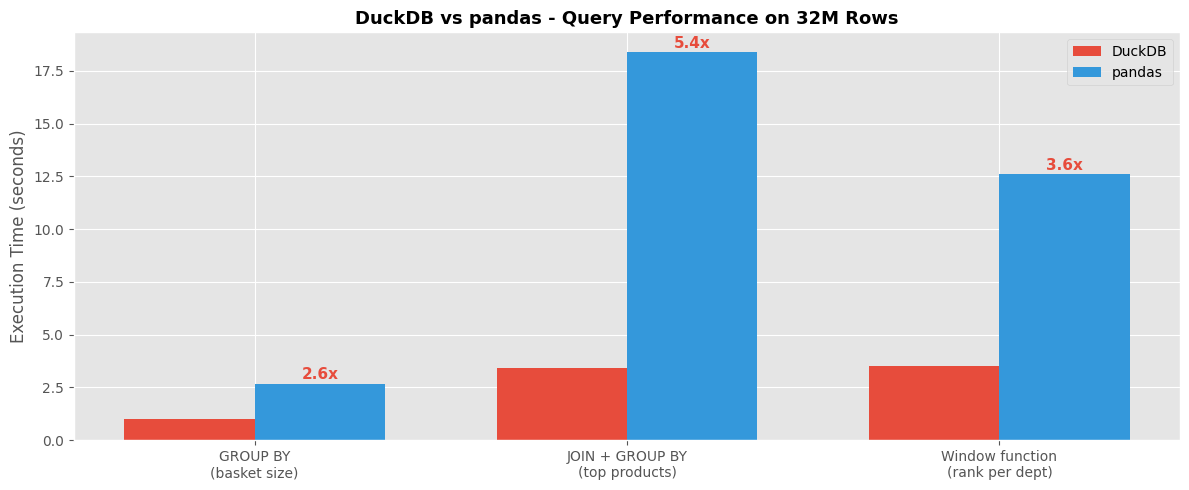

In [14]:
# Visualizing the benchmark results

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(df_bench))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], df_bench['duckdb_s'], width, label='DuckDB', color='#e74c3c')
bars2 = ax.bar([i + width/2 for i in x], df_bench['pandas_s'], width, label='pandas', color='#3498db')

for bar, speedup in zip(bars2, df_bench['speedup']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
            speedup, ha='center', fontsize=11, fontweight='bold', color='#e74c3c')

ax.set_ylabel('Execution Time (seconds)')
ax.set_title('DuckDB vs pandas - Query Performance on 32M Rows', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['GROUP BY\n(basket size)', 'JOIN + GROUP BY\n(top products)', 
                     'Window function\n(rank per dept)'], fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/duckdb_vs_pandas_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Project Diagnosis and Business Findings

### Key business discoveries

**Customer behavior patterns:**
- 206,209 unique customers placed 3.4M orders averaging 16.6 orders per customer, indicating a highly engaged user base
- 54.3% of customers are monthly shoppers, 33.7% biweekly, and 12% weekly. The weekly segment (24,670 customers) is the most valuable despite being the smallest
- Only 5.6% are power users (50+ orders) but they average 68.9 orders each, they are the core revenue drivers
- Median gap between orders is 7 days (weekly cycle), with 50.4% of all reorders happening within a week

**Product insights:**
- Banana is the undisputed king: 472,565 orders, 84.4% reorder rate. 19 of the top 20 products are produce
- Overall reorder rate is 58.97%, meaning customers repurchase more than half of what they buy
- Dairy eggs has the highest reorder rate (66%), personal care the lowest (31%). Staples drive loyalty
- 7 out of 21 departments cover 80% of all orders (Pareto confirmed). Produce alone is 29%

**Operational insights:**
- Sunday and Monday are peak days (not Saturday). Weekend grocery planning drives Sunday volume
- Peak hours: 10 AM - 3 PM across all days. Sunday 2 PM is the absolute peak (~54,000 orders)
- Dead zone: 1 AM - 5 AM (<1,000 orders). Server scaling and delivery scheduling should follow this pattern

### Technical achievements

**DuckDB as an analytical engine:**
- Star schema with 6 tables (3 fact + 3 dimension) created from Parquet in 3.5 seconds
- SQL queries on 32M rows execute in 2-6 seconds with JOINs and window functions
- Persistent .duckdb file eliminates reprocessing on subsequent sessions
- SQL-first approach demonstrates interview-ready analytical skills

**ETL pipeline:**
- CSV to Parquet conversion achieved 4.9x compression on the largest file (550 MB to 112 MB)
- Total storage savings: 680 MB CSV to 145 MB Parquet (4.7x overall)
- Parquet preserves data types, eliminating re-parsing overhead on every load

**Performance benchmark (DuckDB vs pandas on 32M rows):**

| Query | DuckDB | pandas | Speedup |
|-------|--------|--------|---------|
| GROUP BY (basket size) | 1.01s | 2.67s | 2.6x |
| JOIN + GROUP BY (top products) | 3.43s | 18.40s | 5.4x |
| Window function (rank per dept) | 3.50s | 12.62s | 3.6x |

- **Average speedup: 3.9x** across all query types
- JOIN operations showed the largest advantage (5.4x): DuckDB's columnar engine handles multi-table joins natively, while pandas must materialize the full merged DataFrame in memory (990 MB) before aggregating
- pandas loaded 32M rows in 8.3 seconds consuming 990 MB of RAM. DuckDB queries the same data from disk-backed Parquet without loading everything into memory
- The benchmark validates DuckDB as the right tool for analytical queries at scale

In [15]:
# Closing the DuckDB connection and listing project artifacts

con.close()
print("DuckDB connection closed")

# Listing all artifacts
print(f"\n-- Project Artifacts --")
for folder in ['../data', '../data/raw', '../data/parquet', '../outputs']:
    print(f"\n  {folder}/")
    if os.path.exists(folder):
        for f in sorted(os.listdir(folder)):
            filepath = os.path.join(folder, f)
            if os.path.isfile(filepath):
                size = os.path.getsize(filepath) / (1024 * 1024)
                unit = 'MB'
                if size < 1:
                    size *= 1024
                    unit = 'KB'
                print(f"    {f:<45} {size:.1f} {unit}")

DuckDB connection closed

-- Project Artifacts --

  ../data/
    retail_warehouse.duckdb                       145.5 MB

  ../data/raw/
    aisles.csv                                    2.5 KB
    departments.csv                               0.3 KB
    order_products__prior.csv                     550.8 MB
    order_products__train.csv                     23.5 MB
    orders.csv                                    103.9 MB
    products.csv                                  2.1 MB

  ../data/parquet/
    aisles.parquet                                4.3 KB
    departments.parquet                           2.1 KB
    order_products__prior.parquet                 112.4 MB
    order_products__train.parquet                 4.8 MB
    orders.parquet                                26.3 MB
    products.parquet                              1.4 MB

  ../outputs/
    basket_size_distribution.png                  49.6 KB
    customer_segmentation.png                     73.9 KB
    department_paret